In [1]:
# Import Libraries and Configure Matplotlib
%matplotlib inline

import numpy as np
import matplotlib.pyplot as plt
import re
import collections
from matplotlib import cm
from matplotlib import colors
from pycirclize import Circos
from tqdm import tqdm
import glob
import pandas as pd
import sys
import importlib
sys.path.append('../')  # Adjust the path as needed

import utilities.functions as functions
import utilities.circ as circ
# Reload the module to reflect the changes
importlib.reload(functions)
importlib.reload(circ)

<module 'utilities.circ' from '/Users/xuechenkan/potts_model_test/ms0.5/../utilities/circ.py'>

In [2]:
start_aa_IN = 1  # Starting amino acid position
actual_length_IN = 263
start_aa_PR = 1  # Starting amino acid position
actual_length_PR = 99
start_aa_RT = 39  # Starting amino acid position
actual_length_RT = 188
IN_path = '../ms0.5/IN/'
PR_path = '../ms0.5/PR/'
RT_path = '../ms0.5/RT/'
IN_unreduced_seq_path = IN_path + 'data/in.fullseq'
PR_unreduced_seq_path = PR_path + 'data/pr.exper.fullseq'
RT_unreduced_seq_path = RT_path + 'data/rt.fullseq'

IN_kn_path = IN_path+'data/kn.her2.all'
PR_kn_path = PR_path+'data/kn.her2.all'
RT_kn_path = RT_path+'data/kn.her2.all'

IN_redux_dict = functions.get_redu_dict(IN_path+'data/in.reduce4.redux',1)
PR_redux_dict = functions.get_redu_dict(PR_path+'data/pr.reduce4.redux',0)
RT_redux_dict = functions.get_redu_dict(RT_path+'data/rt.reduce4.redux',0)

top_20_DRM_IN = functions.read_list_from_file(IN_path + 'data/top_20_DRM.txt')
bottom_20_DRM_IN = functions.read_list_from_file(IN_path + 'data/bottom_20_DRM.txt')
combined_DRM_IN = top_20_DRM_IN + bottom_20_DRM_IN

top_20_DRM_PR = functions.read_list_from_file(PR_path + 'data/top_20_DRM.txt')
bottom_20_DRM_PR = functions.read_list_from_file(PR_path + 'data/bottom_20_DRM.txt')
combined_DRM_PR = top_20_DRM_PR + bottom_20_DRM_PR

top_20_DRM_RT = functions.read_list_from_file(RT_path + 'data/top_20_DRM.txt')
bottom_20_DRM_RT = functions.read_list_from_file(RT_path + 'data/bottom_20_DRM.txt')
combined_DRM_RT = top_20_DRM_RT + bottom_20_DRM_RT

width = 1.75
width_d2 = width/2
# scale_mode = 'color'
scale_mode = 'cw5'
# scale_mode = 'width'
scale_scale = 'global'
weight_power=2
a = 2
b = 0.4
x_min = 1.8230609
x_max = 33.17926


global_max_dde = 8.50879
global_min_dde = -3.683882
color_red = "#A50F15"
color_blue = "#08519C" 

/var/folders/17/rj19bvws2qscyfjmb7m44zmm0000gn/T/ipykernel_80371/4032367305.py:79: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


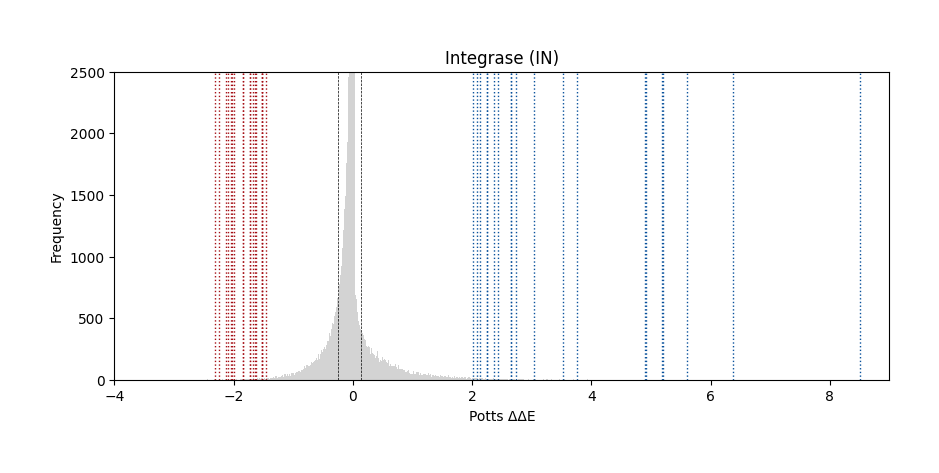

/var/folders/17/rj19bvws2qscyfjmb7m44zmm0000gn/T/ipykernel_80371/4032367305.py:114: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


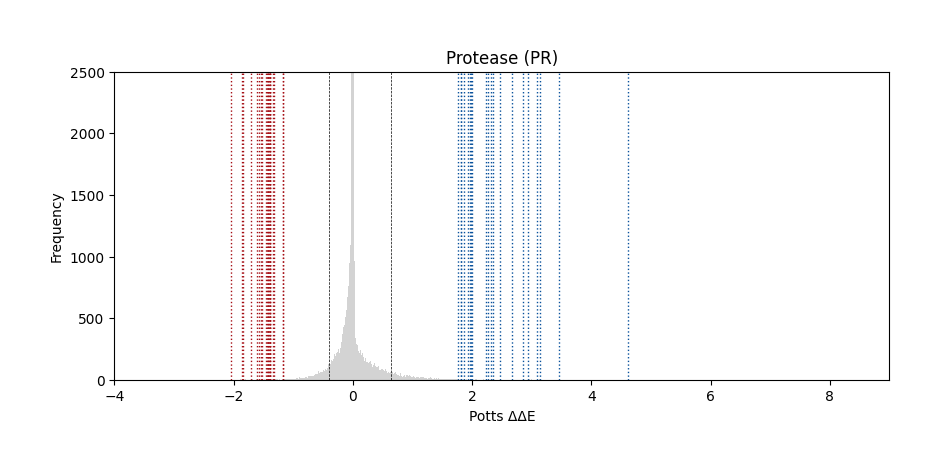

/var/folders/17/rj19bvws2qscyfjmb7m44zmm0000gn/T/ipykernel_80371/4032367305.py:149: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


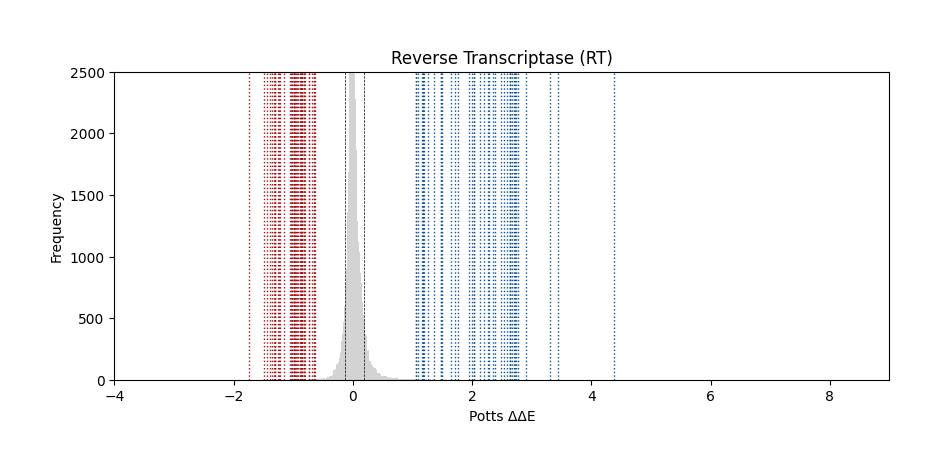

In [3]:
# Define a function to process a file and extract ddE values
chord_norm_b = plt.Normalize(vmin=0, vmax=global_max_dde)
chord_cmap_b = plt.cm.Blues

chord_norm_r = plt.Normalize(vmin=global_min_dde, vmax=0)
chord_cmap_r = plt.cm.Reds_r
def process_kn_file(file_path):
    delta_delta_e_per_pair = []
    with open(file_path) as f:
        for line in f:
            line = line.strip()
            if not line:
                continue

            columns = re.split(r'[,\t\s]+', line)
            mutations = columns[0]
            ddE = float(columns[1])
            positions = [int(pos) for pos in re.findall(r'\d+', mutations)]
            if len(positions) != 2:
                continue

            pos1, pos2 = positions
            delta_delta_e_per_pair.append((pos1, pos2, ddE))

    # Sort by ddE values
    delta_delta_e_per_pair_sorted = sorted(delta_delta_e_per_pair, key=lambda x: x[-1], reverse=True)
    return delta_delta_e_per_pair_sorted

# Process all three files
IN_ddE_pairs = process_kn_file(IN_kn_path)
IN_dde_dict = functions.DDE_dict(IN_kn_path)
PR_ddE_pairs = process_kn_file(PR_kn_path)
PR_dde_dict = functions.DDE_dict(PR_kn_path)
RT_ddE_pairs = process_kn_file(RT_kn_path)
RT_dde_dict = functions.DDE_dict(RT_kn_path)

# Extract ddE values for plotting
IN_ddE_values = [pair[2] for pair in IN_ddE_pairs]
PR_ddE_values = [pair[2] for pair in PR_ddE_pairs]
RT_ddE_values = [pair[2] for pair in RT_ddE_pairs]

# Plot histograms for each protein

# Show IN histogram
# Calculate the 5th and 95th percentiles for IN_ddE_values
percentile_neg = np.percentile(IN_ddE_values, 5)
percentile_pos = np.percentile(IN_ddE_values, 95)

plt.figure(figsize=(10,4))
top_20_reduced = []
for pair in top_20_DRM_IN:
    top_20_reduced.append(functions.unreduced_to_reduced_pair(IN_redux_dict, pair))
for pair in top_20_reduced:
    if pair in IN_dde_dict:
        value = IN_dde_dict[pair]
        color = chord_cmap_b(chord_norm_b(value))
        color = color_blue
        plt.axvline(value, color=color, linestyle=':', linewidth=1)

bottom_20_reduced = []
for pair in bottom_20_DRM_IN:
    bottom_20_reduced.append(functions.unreduced_to_reduced_pair(IN_redux_dict, pair))
for pair in bottom_20_reduced:
    if pair in IN_dde_dict and IN_dde_dict[pair]<-1:
        value = IN_dde_dict[pair]
        dde = IN_dde_dict[pair]
        color = chord_cmap_r(chord_norm_r(value))
        color = color_red
        plt.axvline(value, color=color, linestyle=':', linewidth=1)

plt.hist(IN_ddE_values, bins=1000, color='#d3d3d3')
plt.axvline(percentile_neg, color='black', linestyle='--', linewidth=0.5)
plt.axvline(percentile_pos, color='black', linestyle='--', linewidth=0.5)
plt.xlabel('Potts ΔΔE')
plt.ylabel('Frequency')
plt.title('Integrase (IN)')
plt.xlim(-4, 9)
plt.ylim(0, 2500)
plt.legend()
plt.show()

# Calculate the 5th and 95th percentiles for PR_ddE_values
percentile_neg = np.percentile(PR_ddE_values, 5)
percentile_pos = np.percentile(PR_ddE_values, 95)

plt.figure(figsize=(10,4))
top_20_reduced = []
for pair in top_20_DRM_PR:
    top_20_reduced.append(functions.unreduced_to_reduced_pair(PR_redux_dict, pair))
for pair in top_20_reduced:
    if pair in PR_dde_dict:
        value = PR_dde_dict[pair]
        color = chord_cmap_b(chord_norm_b(value))
        color = color_blue
        plt.axvline(value, color=color, linestyle=':', linewidth=1)

bottom_20_reduced = []
for pair in bottom_20_DRM_PR:
    bottom_20_reduced.append(functions.unreduced_to_reduced_pair(PR_redux_dict, pair))
for pair in bottom_20_reduced:
    if pair in PR_dde_dict:
        value = PR_dde_dict[pair]
        color = chord_cmap_r(chord_norm_r(value))
        color = color_red
        plt.axvline(value, color=color, linestyle=':', linewidth=1)
plt.hist(PR_ddE_values, bins=1000, color='#d3d3d3')
plt.axvline(percentile_neg, color='black', linestyle='--', linewidth=0.5)
plt.axvline(percentile_pos, color='black', linestyle='--', linewidth=0.5)
plt.xlabel('Potts ΔΔE')
plt.ylabel('Frequency')
plt.title('Protease (PR)')
plt.xlim(-4, 9)
plt.ylim(0, 2500)
plt.legend()
plt.show()

# Calculate the 5th and 95th percentiles for RT_ddE_values
percentile_neg = np.percentile(RT_ddE_values, 5)
percentile_pos = np.percentile(RT_ddE_values, 95)

plt.figure(figsize=(10,4))
top_20_reduced = []
for pair in top_20_DRM_RT:
    top_20_reduced.append(functions.unreduced_to_reduced_pair(RT_redux_dict, pair))
for pair in top_20_reduced:
    if pair in RT_dde_dict:
        value = RT_dde_dict[pair]
        color = chord_cmap_b(chord_norm_b(value))
        color = color_blue
        plt.axvline(value, color=color, linestyle=':', linewidth=1)

bottom_20_reduced = []
for pair in bottom_20_DRM_RT:
    bottom_20_reduced.append(functions.unreduced_to_reduced_pair(RT_redux_dict, pair))
for pair in bottom_20_reduced:
    if pair in RT_dde_dict:
        value = RT_dde_dict[pair]
        color = chord_cmap_r(chord_norm_r(value))
        color = color_red
        plt.axvline(value, color=color, linestyle=':', linewidth=1)
plt.hist(RT_ddE_values, bins=1000, color='#d3d3d3')
plt.axvline(percentile_neg, color='black', linestyle='--', linewidth=0.5)
plt.axvline(percentile_pos, color='black', linestyle='--', linewidth=0.5)
plt.xlabel('Potts ΔΔE')
plt.ylabel('Frequency')
plt.title('Reverse Transcriptase (RT)')
plt.xlim(-4, 9)
plt.ylim(0, 2500)
plt.legend()
plt.show()